# Exercise 6. Classification, deep learning

The aim of this exercise is to train a deep learning model for predicting different classes from satellite data. It also assesses the model accuracy with a test dataset. The model training is done using scikit-learn [MLPClassifer](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

**Before starting with this exercise, the general [raster data preparations exercise](../02_raster_data_preparation) must be done.**

## Input data

2 raster files with:

* Coordinate system: Finnish ETRS-TM35FIN, EPSG:3067
* Resolution: 20m

#### Labels

* Multiclass classification raster: 1 - forest, 2 - fields, 3 - water, 0 - everything else.

#### Data image

* Sentinel2 mosaic, with data from 2 different dates (May and July), to have more data values. Dataset has 8 bands based on bands: 2, 3, 4 and 8 on dates: 2021-05-11 and 2021-07-21, reflection values scaled to [0 ... 1]. The bands source data is: 
     *  'b02' / '2021-05-11'
     *  'b02' / '2021-07-21'
     *  'b03' / '2021-05-11'
     *  'b03' / '2021-07-21'
     *  'b04' / '2021-05-11'
     *  'b04' / '2021-07-21'
     *  'b08' / '2021-05-11'
     *  'b08' / '2021-07-21'
     
[Bands](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/): b02=blue, b03=green, b04=red, b08=infrared          

## Results

* Trained deep learning model
* Model accuracy estimation
* Class confusion matrix
* Predicted image 

## Main steps

1) Read data and shape it to suitable form for scikit-learn.
2) Divide the data to training, validation and test datasets.
3) Undersample to balance the training dataset.
4) Train the model.
5) Estimate the model on test data, inc class confusion matrix classification report creation.
6) Predict classification based on the data image and save it.
7) Plot the results

## Imports and paths

In [1]:
import os, time
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
from rasterio.plot import show_hist
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
#import urllib
from joblib import dump, load
%matplotlib inline

In [2]:
# Set folders
user = os.environ.get('USER')
base_folder = os.path.join('/scratch/project_462001167/students', user, 'GeoML')
dataFolder = os.path.join(base_folder,'data/raster')
outputBaseFolder= os.path.join(base_folder,'06_deep_classification_MLP')
shallow_folder= os.path.join(base_folder,'04_shallow_classification')

# Source data local paths
image_file = os.path.join(dataFolder, 'data_shallow.tif')
multiclass_classification_file = os.path.join(dataFolder, 'labels_shallow.tif')

#For comparision
random_forest_predicition = os.path.join(shallow_folder,'classification_random_forest.tif')
hist_gradient_boosting_predicition = os.path.join(shallow_folder,'classification_hist_gradient_boosting.tif')


# Available cores. 
n_jobs = len(os.sched_getaffinity(0))

## Read data and shape it to suitable form for scikit-learn¶

Read the input datasets with Rasterio and shape it to suitable form for keras (same as for scikit-learn).

Exactly the same as for shallow classification data.

### Satellite image

The satellite image has 8 channels, so rasterio reads it in as 3D data cube.

For keras we reshape the data to 2D, having in dataframe one row for each pixel. Each pixel has eight values, one for each band/date.

In [3]:
# Read the pixel values from .tif file as dataframe
with rasterio.open(image_file) as image_dataset:
    image_data = image_dataset.read() 

# Check shape of input data
print ('Dataframe original shape, 3D: ', image_data.shape)    

Dataframe original shape, 3D:  (8, 1000, 1000)


Save number of bands for later, to be able to reshape data back to 2D.

In [4]:
no_bands_in_image = image_data.shape[0]
no_bands_in_image

8

As a mid-step transponse the axis order, so that the bands are the last. Notice how the dataframe size changes.

In [5]:
image_data2 = np.transpose(image_data, (1, 2, 0))
# Check again the data shape, now the bands should be last.
print ('Dataframe shape after transpose, 3D: ', image_data2.shape) 

Dataframe shape after transpose, 3D:  (1000, 1000, 8)


In [6]:
# Then reshape to 2D.
pixels = image_data2.reshape(-1, no_bands_in_image)
print ('Dataframe shape after transpose and reshape, 2D: ', pixels.shape) 

Dataframe shape after transpose and reshape, 2D:  (1000000, 8)


### Labels

Do the same for labels.

In [7]:
# For labels only reshape to 1D is enough.
with rasterio.open(multiclass_classification_file) as labels_src:
    labels_data = labels_src.read()
    input_labels = labels_data.reshape(-1)
    print ('Labels shape after reshape, 1D: ', input_labels.shape)

Labels shape after reshape, 1D:  (1000000,)


Save the number of classes in labels, it will be later needed for defining the last layer in the model.

In [8]:
number_of_classes = np.unique(labels_data).size
number_of_classes

4

### Divide the data to training and test datasets

Set training, validation and test data ratios, how big part of the pixels is assigned to different sets.

In [9]:
train_ratio = 0.7
validation_ratio = 0.2
test_ratio = 0.1

Separate test set. MLPClassifier splits validation data itself, so we do not prepare it here.

In [10]:
x_train0, x_test, y_train0, y_test = train_test_split(pixels, input_labels, test_size=test_ratio, random_state=63, stratify=input_labels)

### Resample to balance the dataset

The classes are very imbalanced in the dataset, so undersample the majority classes in the training set, so that all classes are represented about similar number of pixels. 
Notice that validation and test set keep the original class-distribution.

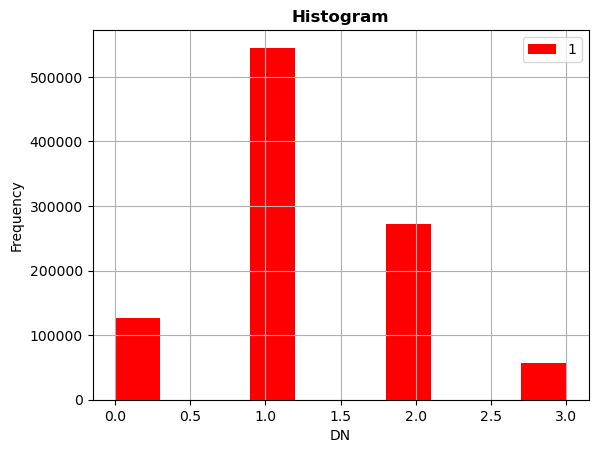

In [11]:
show_hist(labels_data)

In [12]:
# The classes are very imbalanced, so undersample the majority classes
rus = RandomUnderSampler(random_state=63)
x_train, y_train = rus.fit_resample(x_train0, y_train0)   
print ('Dataframe shape after undersampling of majority classes, pixels 2D: ', x_train.shape)
print ('Dataframe shape after undersampling of majority classes, labels 2D: ', y_train.shape)

Dataframe shape after undersampling of majority classes, pixels 2D:  (202756, 8)
Dataframe shape after undersampling of majority classes, labels 2D:  (202756,)


*How many pixels of different classes are included in training dataset?*

Notice that we lost a lot of pixel at this point, in real cases that may be undesired. See [inbalanced-learn User guide](https://imbalanced-learn.org/stable/user_guide.html#user-guide) for other options.

In [13]:
print('Labels before splitting:           ', np.unique(input_labels, return_counts=True)[1])
print('Training data before undersampling:', np.unique(y_train0, return_counts=True)[1])
print('Training data after undersampling: ', np.unique(y_train, return_counts=True)[1])
print('Test data:                         ', np.unique(y_test, return_counts=True)[1])

Labels before splitting:            [125813 545119 272747  56321]
Training data before undersampling: [113232 490607 245472  50689]
Training data after undersampling:  [50689 50689 50689 50689]
Test data:                          [12581 54512 27275  5632]


## Train the MLP model

[scikit-learn MLPClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [14]:
def trainModel(x_train, y_train, clf, classifierName):
    start_time = time.time()    
    clf.fit(x_train, y_train)
    print('Model training took: ', round((time.time() - start_time), 2), ' seconds')
    
    # Save the model to a file
    modelFilePath = os.path.join(outputBaseFolder, ('model_' + classifierName + '.sav'))
    dump(clf, modelFilePath) 
    return clf

In [15]:
classifierName = 'mlp'
# Initialize the MLP classifier and give the hyperparameters.
mlp_classifier = MLPClassifier(hidden_layer_sizes=(128,64,32,16), activation='relu', 
                                          solver='adam', early_stopping=True, batch_size=256, random_state=63,
                                          validation_fraction=validation_ratio, n_iter_no_change=10)
mlp_classifier = trainModel(x_train, y_train, mlp_classifier, classifierName)

Model training took:  60.18  seconds


*Please, be patient, this takes a moment*
 - `hidden_layer_sizes` - how many and how big hidden layers to use, try to modify the number of layers or size of layers.
 - `Adam optimizer`, often used, scikit-learn supports also a few others

Plot the train loss of the latest model fitting

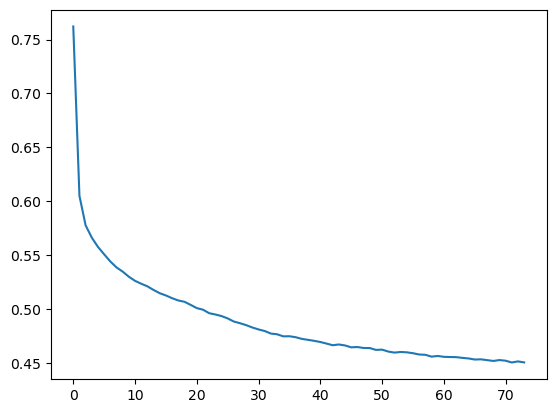

In [16]:
plt.plot(mlp_classifier.loss_curve_)
plt.show()

Plot the validation accuracy

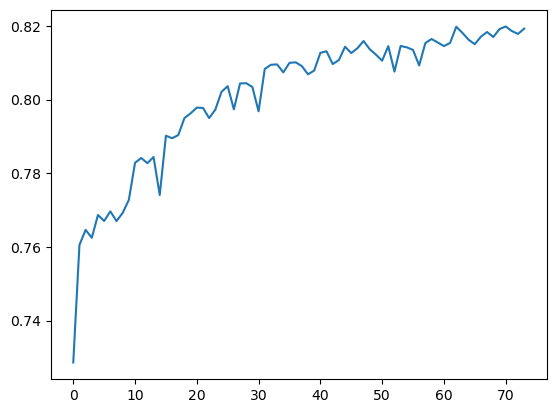

In [17]:
plt.plot(mlp_classifier.validation_scores_)
plt.show()

In [18]:
print("Accuracy of the model with training data:", mlp_classifier.score(x_train, y_train))

Accuracy of the model with training data: 0.8216526268026594


### Estimate the model with test data

Model is estimated with test data. Both confusion matrix and classification report are generated.

In [19]:
def estimateModel(clf, x_test, y_test):
    test_predictions = clf.predict(x_test)
    print('Classification report: \n', classification_report(y_test, test_predictions))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, normalize='true', cmap=plt.cm.Blues)

Classification report: 
               precision    recall  f1-score   support

         0.0       0.42      0.65      0.51     12581
         1.0       0.95      0.82      0.88     54512
         2.0       0.85      0.84      0.84     27275
         3.0       0.89      0.96      0.93      5632

    accuracy                           0.81    100000
   macro avg       0.78      0.82      0.79    100000
weighted avg       0.85      0.81      0.83    100000



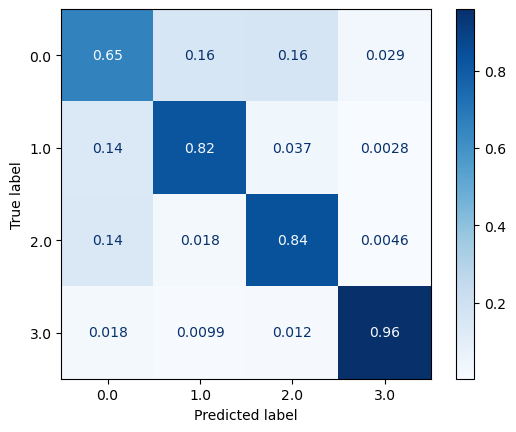

In [20]:
estimateModel(mlp_classifier, x_test, y_test) #Test data

## Predict classification based on the data image and save it

In [21]:
def predictImage(modelName):
    start_time = time.time()    
    
    #Set file paths
    classifiedImageFile = os.path.join(outputBaseFolder, ('classification_' + modelName + '.tif'))
    modelFile = os.path.join(outputBaseFolder, ('model_' + modelName + '.sav'))    
         
    #Load the model from the saved file
    trained_model = load(modelFile)

    # predict the class for each pixel
    prediction = trained_model.predict(pixels)

    # Reshape back to 2D
    print('Prediction shape in 1D: ', prediction.shape)
    prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2]))
    print('Prediction shape in 2D: ', prediction2D.shape)

    # Save the results as .tif file.
    # Copy metadata from the labels image 
    outputMeta = labels_src.meta
    # Writing the image on the disk
    with rasterio.open(classifiedImageFile, 'w', **outputMeta) as dst:
        dst.write(prediction2D, 1)
    print('Predicting took: ', round((time.time() - start_time), 1), ' seconds')


In [22]:
predictImage('mlp')

Prediction shape in 1D:  (1000000,)
Prediction shape in 2D:  (1000, 1000)
Predicting took:  0.9  seconds


## Plot the results

<Axes: title={'center': 'Histogram-based Gradient Boosting Classification Tree'}>

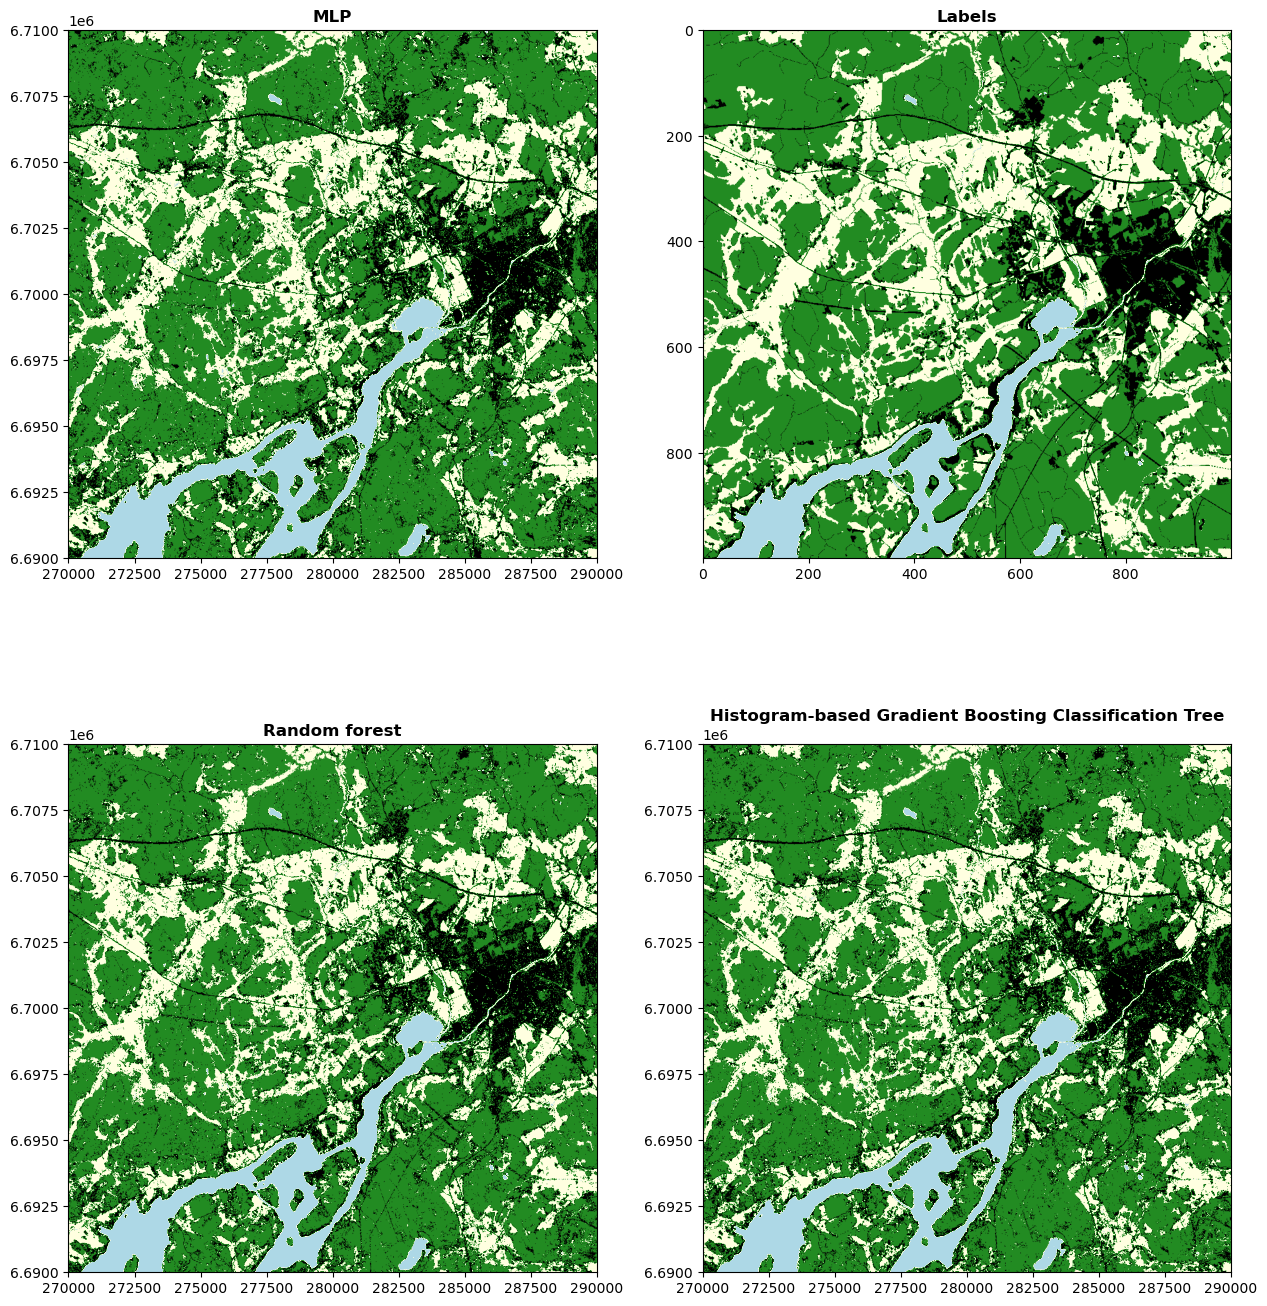

In [23]:
### Create a subplot for 4 images and plot the sentinel image 
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(15, 17))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black", "forestgreen", "lightyellow", "lightblue"])

### The results
rf_results = rasterio.open(random_forest_predicition)
sgd_results = rasterio.open(hist_gradient_boosting_predicition)
mlp_results = os.path.join(outputBaseFolder, ('classification_' + classifierName + '.tif'))
mlp_results = rasterio.open(mlp_results)

show(mlp_results, ax=ax[0, 0], cmap=cmap, title='MLP')
show(labels_data, ax=ax[0,1], cmap=cmap, title='Labels')
show(rf_results, ax=ax[1, 0], cmap=cmap, title='Random forest')
show(sgd_results, ax=ax[1, 1], cmap=cmap, title='Histogram-based Gradient Boosting Classification Tree')


## Class level predictions

The above predicted the most likely class. Some Classifiers in `scikit-learn` have option also to get probabilities for all classes, inc MLP and Random forest.

Define function to get for each pixel probabilities for each class.

In [24]:
def predictProbabilities(modelName):
    start_time = time.time()    
    
    #Set file paths
    classifiedImageFile = os.path.join(outputBaseFolder, ('classification_' + modelName + 'probabilities.tif'))
    modelFile = os.path.join(outputBaseFolder, ('model_' + modelName + '.sav'))    
         
    #Load the model from the saved file
    trained_model = load(modelFile)

    # predict the class for each pixel
    prediction = trained_model.predict_proba(pixels)

    # Reshape back to 2D
    print('Prediction shape in 2D: ', prediction.shape)
    prediction2D = np.reshape(prediction, (image_data.shape[1], image_data.shape[2], number_of_classes))
    print('Prediction shape in 3D: ', prediction2D.shape)

    prediction2D = np.transpose(prediction2D, (2, 0, 1))
    print('Prediction shape in 3D: ', prediction2D.shape)


    # Save the results as .tif file.
    # Copy metadata from the labels image 
    outputMeta = labels_src.meta
    outputMeta['count'] = number_of_classes
    # Writing the image on the disk
    with rasterio.open(classifiedImageFile, 'w', **outputMeta) as dst:
        dst.write(prediction2D)
    print('Predicting took: ', round((time.time() - start_time), number_of_classes), ' seconds')
    return prediction2D

Get probabilities for MLP model.

In [25]:
pixel_predictions = predictProbabilities('mlp')
#outputBaseFolder= os.path.join(base_folder,'04_shallow_classification')
#pixel_predictions = predictProbabilities('random_forest')

Prediction shape in 2D:  (1000000, 4)
Prediction shape in 3D:  (1000, 1000, 4)
Prediction shape in 3D:  (4, 1000, 1000)
Predicting took:  0.9344  seconds


Plot the probabilieis for all classes, most likely class and ground truth.

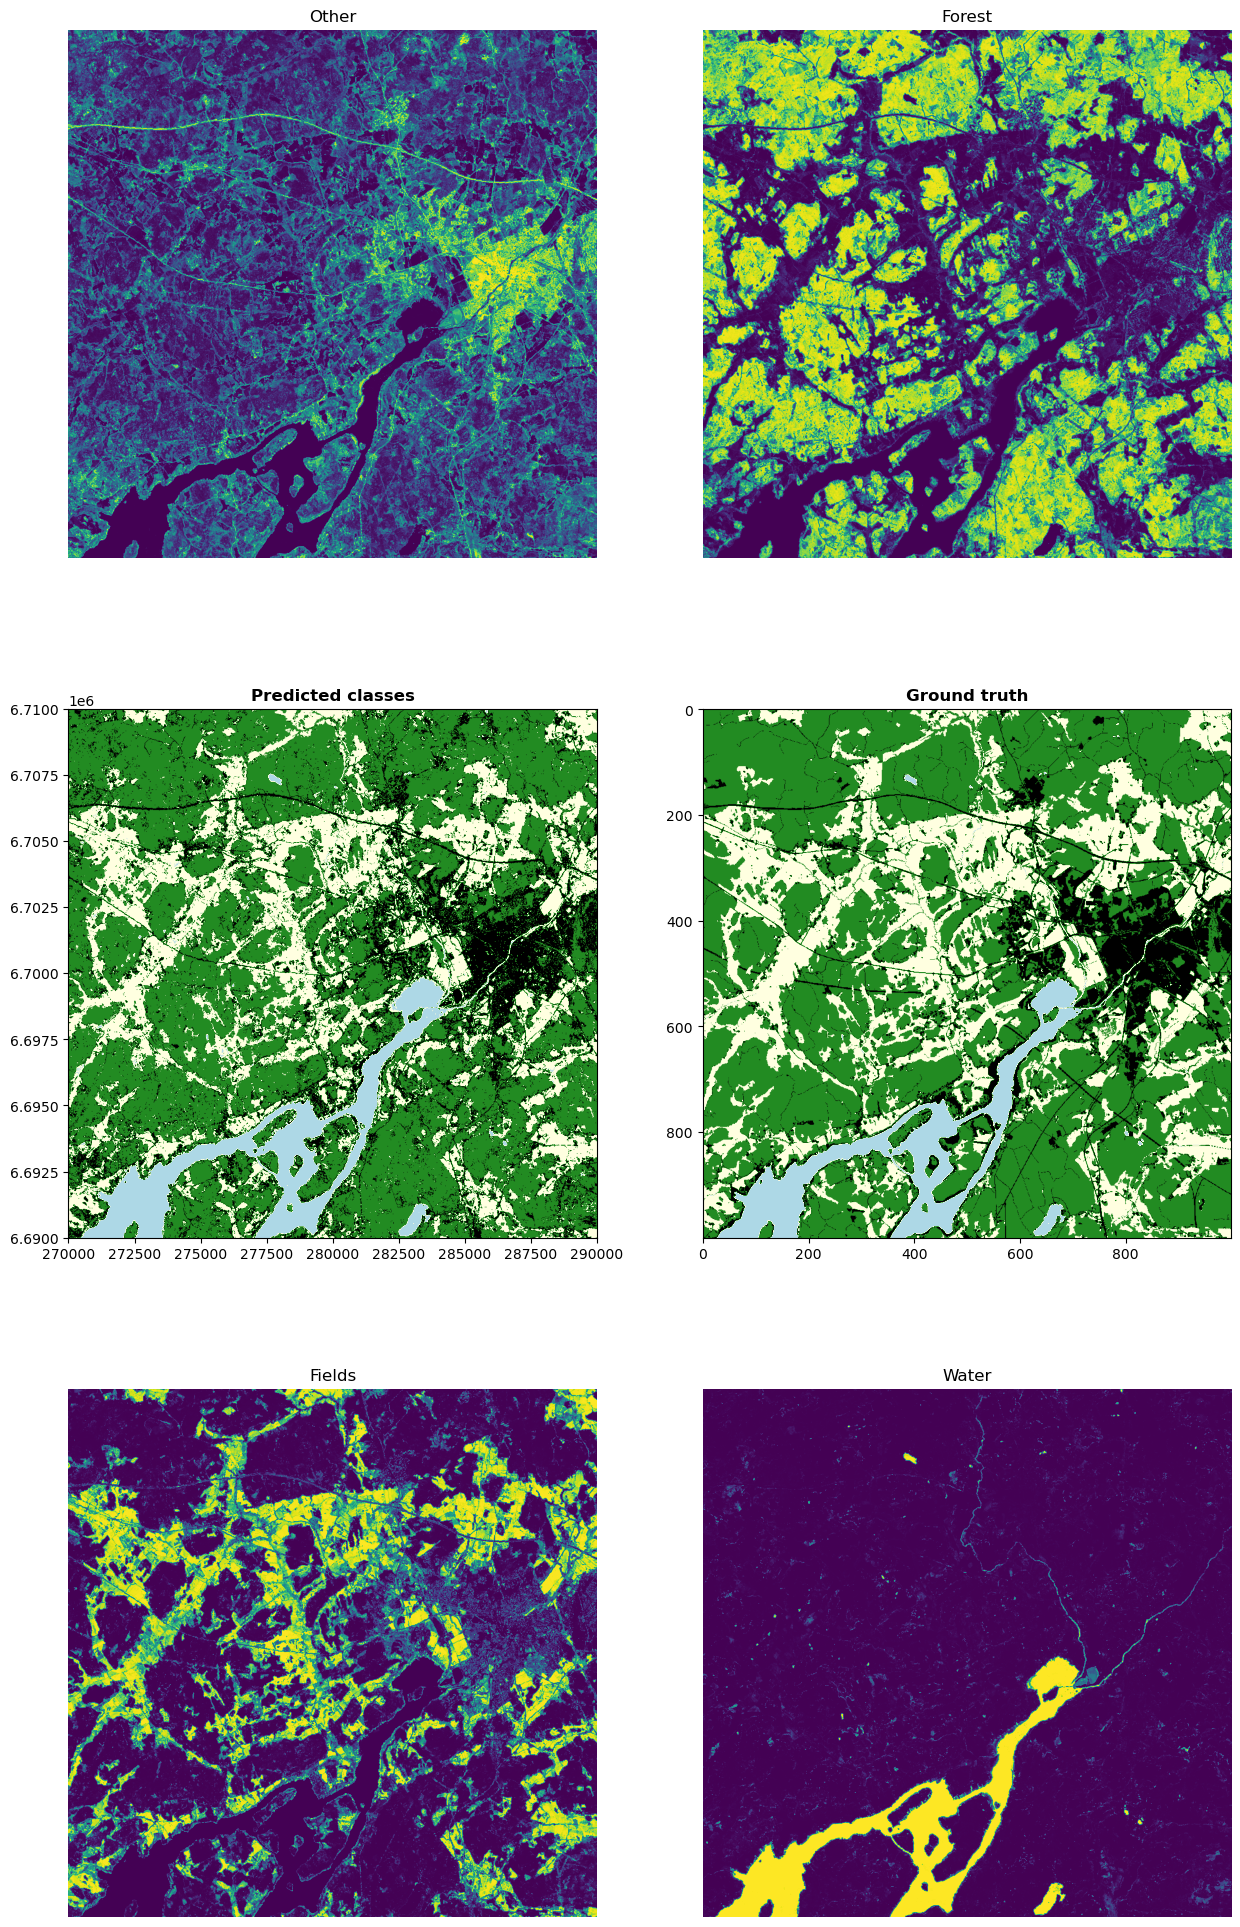

In [26]:
fig, axes = plt.subplots(3, 2, figsize=(15, 25))

# Other
axes[0, 0].imshow(pixel_predictions[0])
axes[0, 0].set_title("Other")
axes[0, 0].axis("off")

# Forest
axes[0, 1].imshow(pixel_predictions[1])
axes[0, 1].set_title("Forest")
axes[0, 1].axis("off")

# Fields
axes[2, 0].imshow(pixel_predictions[2])
axes[2, 0].set_title("Fields")
axes[2, 0].axis("off")

# Water
axes[2, 1].imshow(pixel_predictions[3])
axes[2, 1].set_title("Water")
axes[2, 1].axis("off")

# Predicted classes
show(mlp_results, ax=axes[1, 0], cmap=cmap, title='Predicted classes')

# Ground truth
show(labels_data, ax=axes[1, 1], cmap=cmap, title='Ground truth')

plt.show()